In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os 
import sys
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix
sys.path.append(os.path.abspath(".."))
from src.svm.Support_Vector_Machine import SVM
from sklearn.preprocessing import StandardScaler




In [3]:
df=pd.read_csv("../data/ionosphere_data_kaggle.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 35 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature1   351 non-null    int64  
 1   feature2   351 non-null    int64  
 2   feature3   351 non-null    float64
 3   feature4   351 non-null    float64
 4   feature5   351 non-null    float64
 5   feature6   351 non-null    float64
 6   feature7   351 non-null    float64
 7   feature8   351 non-null    float64
 8   feature9   351 non-null    float64
 9   feature10  351 non-null    float64
 10  feature11  351 non-null    float64
 11  feature12  351 non-null    float64
 12  feature13  351 non-null    float64
 13  feature14  351 non-null    float64
 14  feature15  351 non-null    float64
 15  feature16  351 non-null    float64
 16  feature17  351 non-null    float64
 17  feature18  351 non-null    float64
 18  feature19  351 non-null    float64
 19  feature20  351 non-null    float64
 20  feature21 

c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


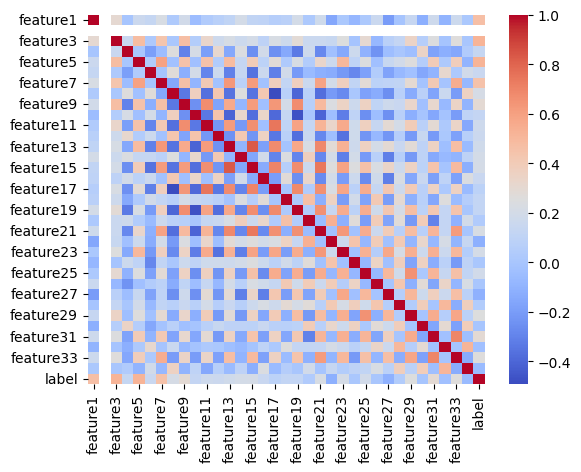

In [5]:
X=df.drop(columns=['label']).values
scaler=StandardScaler()
X=scaler.fit_transform(X)
encoder=LabelEncoder()

df['label']=encoder.fit_transform(df[['label']])
Y=df['label'].values
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [9]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
model=SVM(rbf=True,C=2,gamma=0.5)
model.fit(x_train,y_train)



     pcost       dcost       gap    pres   dres
 0: -7.3259e+01 -1.1769e+03  3e+03  8e-01  8e-16
 1: -6.9286e+01 -4.0722e+02  3e+02  2e-15  5e-16
 2: -8.1413e+01 -1.1657e+02  4e+01  3e-15  5e-16
 3: -8.3740e+01 -8.8700e+01  5e+00  9e-16  2e-16
 4: -8.4221e+01 -8.4977e+01  8e-01  4e-16  2e-16
 5: -8.4318e+01 -8.4501e+01  2e-01  7e-16  2e-16
 6: -8.4347e+01 -8.4359e+01  1e-02  2e-15  2e-16
 7: -8.4350e+01 -8.4350e+01  4e-04  7e-16  2e-16
 8: -8.4350e+01 -8.4350e+01  1e-05  3e-15  2e-16
Optimal solution found.


In [10]:
y_test=np.where(y_test>0,1,-1)
accuracy=accuracy_score(y_test,model.predict(x_test))
print("Accuracy:",accuracy*100)


Accuracy: 95.77464788732394
